In [11]:
import  matplotlib.pyplot as plt
import numpy as np
from scipy.stats import multivariate_normal
import random as rn
import scipy.ndimage
from scipy.interpolate import griddata
import numpy.ma as ma
from numpy.random import uniform, seed
import time
import eif as iso
import seaborn as sb
from sklearn.ensemble import IsolationForest

In [12]:
# Create data
n_records = 5000
n_dimensions = 40
np.random.seed(1)

X = np.random.uniform(0, 1, (n_records, n_dimensions))

In [13]:
rng = np.random.RandomState(42)

In [14]:
Ntrees = 2000
Nsamples = 256

In [10]:
ss = time.time()
F2 = iso.iForest(X, ntrees=Ntrees, sample_size=Nsamples, extension_level=n_dimensions-1, seed=42, parallel=True)
S2 = F2.compute_paths(X_in=X)
ee = time.time()

KeyboardInterrupt: 

In [11]:
print('{:.3f} sec, EIF non-parallel Cython Version'.format(ee-ss))

18.136 sec, EIF non-parallel Cython Version


In [12]:
ss = time.time()
F3 = iso.iForest(X, ntrees=Ntrees, sample_size=Nsamples, extension_level=n_dimensions-1, seed=42, parallel=True)
S3 = F3.compute_paths(X_in=X)
ee = time.time()


In [7]:
print('{:.3f} sec, EIF parallel Cython Version'.format(ee-ss))

4.501 sec, EIF parallel Cython Version


Text(0.5, 0, 'Scores')

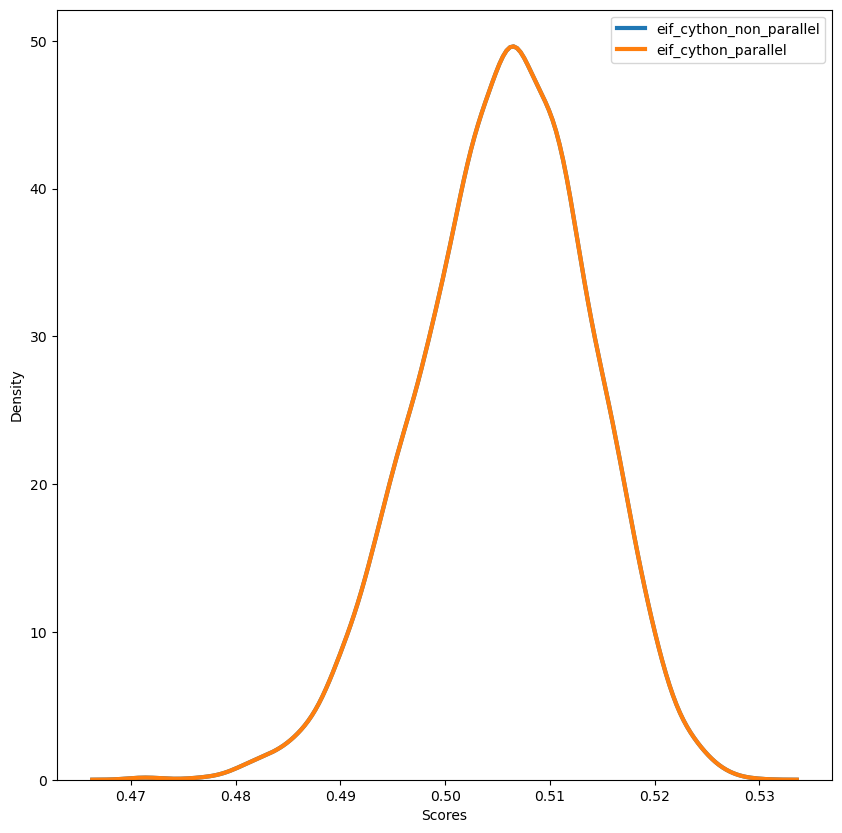

In [19]:
plt.figure(figsize=(10,10))
sb.kdeplot(S2, lw=3, label='eif_cython_non_parallel',  clip=(0.35, 0.8))
sb.kdeplot(S3, lw=3, label='eif_cython_parallel',  clip=(0.35, 0.8))
plt.legend(loc=0)
plt.xlabel('Scores')